In [7]:
import os
from google.colab import drive
drive.mount('/content/drive')
!rm -rf /content/DeepHedging

!git clone https://github.com/shuyizhang01/DeepHedging-ElicitableCVaR.git /content/DeepHedging
import sys
sys.path.insert(0, "/content/DeepHedging/src")

from envs.HedgingEnv import HedgingEnv
from envs.DCCGARCH import DCCGARCHSimulator
from data.calibration import calibrate
from pricing.basket import BasketOptionValuationSystem

import yaml
import numpy as np
import torch
from datetime import datetime

# -- load config --
with open("/content/DeepHedging/cfgs/configDynamicRisk.yaml", "r") as f:
    cfg = yaml.safe_load(f)

garch_cfg = cfg["garch_params"]
garch_params = {
    i: {
        "omega":           garch_cfg[i]["omega"],
        "alpha":           garch_cfg[i]["alpha"],
        "beta":            garch_cfg[i]["beta"],
        "gamma":           garch_cfg[i]["gamma"],
        "lambda":          garch_cfg[i]["lambda"],
        "h_unconditional": garch_cfg[i]["h_unconditional"],
    }
    for i in range(len(garch_cfg))
}

# -- run calibration --
end_date = datetime.strptime(cfg["market"]["end_date"], "%Y-%m-%d") \
           if cfg["market"]["end_date"] else None

cal = calibrate(
    tickers      = cfg["market"]["tickers"],
    garch_params = garch_params,
    years_back   = cfg["market"]["years_back"],
    end_date     = end_date,
)

print(f"Q_bar:\n{cal['Q_bar']}")
print(f"dcc_alpha={cal['dcc_alpha']:.6f}, dcc_beta={cal['dcc_beta']:.6f}, nu_Q={cal['nu_Q']:.4f}")

# -- build simulator --
simulator = DCCGARCHSimulator(
    params    = garch_params,
    Q_bar     = cal["Q_bar"],
    dcc_alpha = cal["dcc_alpha"],
    dcc_beta  = cal["dcc_beta"],
    nu_Q      = cal["nu_Q"],
    r_daily   = cfg["market"]["r_daily"],
    device    = cfg["device"],
)

pricing_path = "/content/DeepHedging/src/pricing/basket_system_dcc_trained (2).pkl"
system = BasketOptionValuationSystem.load(pricing_path)

# -- build env --
env_cfg = cfg["env"]

env = HedgingEnv(
    simulator        = simulator,
    system           = system,
    K                = env_cfg["K"],
    T_days           = env_cfg["T_days"],
    S0               = env_cfg["S0"],
    r                = env_cfg["r"],
    transaction_cost = env_cfg["transaction_cost"],
    basket_weights   = env_cfg["basket_weights"],
)

print(f"\nenv.T_days     = {env.T_days}")
print(f"env.n_assets   = {env.n_assets}")
print(f"env.state_dim  = {env.state_dim}")
print(f"env.action_dim = {env.action_dim}")
print(f"basket_weights = {env.basket_weights.tolist()}")
import sys
sys.path.insert(0, "/content/DeepHedging/src")

import re
import torch
import numpy as np
from pathlib import Path
from agents.DynamicRiskModel import Actor, Critic_VaR_Excess
from agents.StaticRiskModel import MLPActorStatic

n_groups   = 18
group_size = int(env.T_days / n_groups)
print(f"group_size: {group_size}")

# =========================================================================
# LOAD DYNAMIC MODELS
# =========================================================================
repo_path         = "/content/DeepHedging"
dynamic_risk_path = Path(repo_path) / "DynamicRisk"

model_folders = [f for f in dynamic_risk_path.rglob('*') if (f / 'actor.pt').exists()]

all_models = {}
all_norms  = {}

for folder in model_folders:
    parts  = folder.parts
    alpha  = next((p for p in parts if p.startswith('alpha')), None)
    if alpha is None:
        print(f"Skipping {folder}: no alpha folder found")
        continue

    scoring = folder.name
    if scoring == alpha:
        print(f"Skipping {folder}: scoring == alpha")
        continue

    print(f"Loading dynamic model: {alpha} / {scoring}")

    # -- actor --
    try:
        actor_loaded = Actor(
            state_dim=env.state_dim,
            action_dim=env.action_dim,
            hidden_dim=256,
            fixed_std=1e-3,
        )
        actor_loaded.load_state_dict(
            torch.load(folder / "actor.pt", map_location='cpu', weights_only=False)
        )
        actor_loaded.eval()
    except Exception as e:
        print(f"  ✗ actor.pt failed: {e}"); continue

    # -- critics --
    critics_path        = folder / "critics.pt"
    critics_state_dicts = None
    wo                  = False
    for wo in [False, True]:
        try:
            critics_state_dicts = torch.load(critics_path, map_location='cpu', weights_only=wo)
            print(f"  ✓ critics.pt loaded (weights_only={wo})")
            break
        except Exception as e:
            print(f"  ✗ critics.pt failed (weights_only={wo}): {e}")

    if critics_state_dicts is None:
        size = critics_path.stat().st_size if critics_path.exists() else 0
        print(f"  ✗ Skipping {alpha}/{scoring} — critics.pt unreadable ({size} bytes)")
        continue

    critics = []
    try:
        for i in range(n_groups):
            c = Critic_VaR_Excess(
                state_dim=env.state_dim,
                group_size=group_size,
                head_dim_var=128,
                head_dim_excess=128,
            )
            sd = critics_state_dicts[str(i)] if isinstance(critics_state_dicts, dict) else critics_state_dicts[i]
            c.load_state_dict(sd)
            c.eval()
            critics.append(c)
    except Exception as e:
        print(f"  ✗ Failed to instantiate critics: {e}"); continue

    # -- checkpoint / b_values --
    try:
        k_steps  = "390" if alpha == "alpha99" else "300"
        ckpt_path = folder / f"checkpoint_k{k_steps}{scoring}{alpha}.pt"
        ckpt      = torch.load(ckpt_path, map_location='cpu', weights_only=wo)
    except Exception as e:
        print(f"  ✗ Failed to load checkpoint: {e}"); continue

    all_models.setdefault(alpha, {})[scoring] = {"actor": actor_loaded, "critics": critics}
    all_norms.setdefault(alpha,  {})[scoring] = {"b_values": ckpt['b_list']}
    print(f"  ✓ {alpha}/{scoring} loaded | b_values: {all_norms[alpha][scoring]}")

# =========================================================================
# LOAD STATIC MODELS
# =========================================================================
static_risk_path = Path(repo_path) / "StaticRisk"

alpha_str_map = {
    "0.925": "alpha925",
    "0.95":  "alpha95",
    "0.975": "alpha975",
    "0.99":  "alpha99",
}

all_static_models = {}

for pth_file in sorted(static_risk_path.glob("static_actor_alpha*PG.pth")):
    match = re.search(r"alpha([0-9]*\.?[0-9]+)", pth_file.stem)
    if not match:
        print(f"Skipping {pth_file.name}: could not parse alpha"); continue

    alpha_key = alpha_str_map.get(match.group(1))
    if alpha_key is None:
        print(f"Skipping {pth_file.name}: unrecognized alpha"); continue

    print(f"Loading static model: {alpha_key}")
    try:
        static_actor = MLPActorStatic(
            state_dim=env.state_dim,
            action_dim=env.action_dim,
            hidden_dim=256,
        )
        static_actor.load_state_dict(
            torch.load(pth_file, map_location='cpu', weights_only=False)
        )
        static_actor.eval()
        all_static_models[alpha_key] = {"actor": static_actor}
        print(f"  ✓ {alpha_key} static actor loaded")
    except Exception as e:
        print(f"  ✗ Failed to load {pth_file.name}: {e}")

print("\n=== Loaded Dynamic Models ===")
for alpha, funcs in all_models.items():
    for func in funcs:
        print(f"  {alpha} -> {func} -> actor + {len(funcs[func]['critics'])} critics")

print("\n=== Loaded Static Models ===")
for alpha in all_static_models:
    print(f"  {alpha} -> static actor")
# ================================================================
# run_all_plots.py
# ================================================================
import os, sys, re, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from datetime import datetime, timedelta

import yaml
import yfinance as yf
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import rankdata, t
from scipy.special import gammaln
import importlib, sys

# ================================================================
# Load config
# ================================================================
REPO = Path('/content/DeepHedging')

with open(REPO / 'cfgs/configDynamicRisk.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# ── market ────────────────────────────────────────────────────────
TICKERS      = list(cfg['market']['tickers'].keys())   # ['JPM','BAC','WFC','C']
YEARS_BACK   = cfg['market']['years_back']
END_DATE_STR = cfg['market']['end_date']               # "2025-12-20" or null
R_DAILY      = cfg['market']['r_daily']

# ── GARCH ─────────────────────────────────────────────────────────
GARCH_PARAMS = {int(k): v for k, v in cfg['garch_params'].items()}

# ── DCC ───────────────────────────────────────────────────────────
NU_Q_PRETRAINED = cfg['dcc']['nu_Q']          # 4.9204 (used if not None)
DCC_ALPHA_INIT  = cfg['dcc']['dcc_alpha']     # None  → re-fit from data
DCC_BETA_INIT   = cfg['dcc']['dcc_beta']      # None  → re-fit from data

# ── env ───────────────────────────────────────────────────────────
ENV_K               = cfg['env']['K']
ENV_T_DAYS          = cfg['env']['T_days']
ENV_S0              = cfg['env']['S0']
ENV_R               = cfg['env']['r']
ENV_TC              = cfg['env']['transaction_cost']
BASKET_WEIGHTS      = cfg['env']['basket_weights']

# ── pricing ───────────────────────────────────────────────────────
# Resolve pricing system path relative to repo root
_pricing_path_raw = cfg['pricing']['system_path']
PRICING_SYSTEM_PATH = str(REPO / 'src/pricing' / _pricing_path_raw)

# ── actor / critic ────────────────────────────────────────────────
HIDDEN_DIM      = cfg['actor']['hidden_dim']
FIXED_STD       = cfg['actor']['fixed_std']
HEAD_DIM_VAR    = cfg['critic']['head_dim_var']
HEAD_DIM_EXCESS = cfg['critic']['head_dim_excess']

# ── training ──────────────────────────────────────────────────────
N_GROUPS    = cfg['training']['n_groups']
ALPHA_FLOAT = cfg['training']['alpha']                 # 0.95
SCORING_FN  = cfg['training']['scoring_fn']            # "power03"
ALPHA_LABEL = f"alpha{int(ALPHA_FLOAT * 100)}"         # "alpha95"

# ── misc ──────────────────────────────────────────────────────────
SEED   = cfg['seed']
DEVICE = cfg['device'] if torch.cuda.is_available() else 'cpu'

GROUP_SIZE = ENV_T_DAYS // N_GROUPS   # 252 // 18 = 14

print(f"Config loaded → alpha={ALPHA_FLOAT}  scoring={SCORING_FN}  "
      f"n_groups={N_GROUPS}  device={DEVICE}")
print(f"head_dim_var={HEAD_DIM_VAR}  head_dim_excess={HEAD_DIM_EXCESS}  "
      f"group_size={GROUP_SIZE}")

# ── paths ─────────────────────────────────────────────────────────
DATA_DIR = str(REPO / 'content/data')
SAVE_DIR = str(REPO / 'figures')
os.makedirs(SAVE_DIR, exist_ok=True)

# ================================================================
# Remove any cached modules from the old clone, then reimport
# ================================================================
mods_to_remove = [key for key in sys.modules if key.startswith('src')]
for mod in mods_to_remove:
    del sys.modules[mod]

sys.path.insert(0, str(REPO))

import src.visualization.plot as _plot_mod
importlib.reload(_plot_mod)

from src.visualization.plot import (
    plot_g2_functions, plot_portfolio_delta, plot_pnl_distributions,
    plot_scoring_curvature, plot_extreme_trajectory,
    plot_dynamic_risk_comparison, plot_validation_risk,
    plot_initial_dynamic_cvar, plot_actor_critic_loss, plot_mean_action,
)
from src.agents.DynamicRiskModel      import Actor, Critic_VaR_Excess
from src.agents.StaticRiskModel       import MLPActorStatic
from src.envs.HedgingEnv              import HedgingEnv
from src.envs.DCCGARCH                import DCCGARCHSimulator
from src.pricing.basket               import BasketOptionValuationSystem
from src.risk_measures.loss_functions import SCORE_FUNCTIONS
from src.agents.NestedCriticsModel import CriticCVaR

score_fn = SCORE_FUNCTIONS[SCORING_FN]

# ================================================================
# Download market data
# ================================================================
end_date   = datetime.strptime(END_DATE_STR, '%Y-%m-%d') if END_DATE_STR else datetime.today()
start_date = end_date - timedelta(days=365 * YEARS_BACK)

raw = yf.download(
    tickers=TICKERS,
    start=start_date.strftime('%Y-%m-%d'),
    end=end_date.strftime('%Y-%m-%d'),
    progress=False, auto_adjust=False, threads=False,
)['Close']
raw.columns = TICKERS
prices = raw.replace([np.inf, -np.inf], np.nan).dropna()

ratio       = prices.values / np.roll(prices.values, 1, axis=0)
ratio[~np.isfinite(ratio) | (ratio <= 0)] = np.nan
log_returns = pd.DataFrame(
    np.log(ratio), index=prices.index, columns=prices.columns
).dropna()
returns_matrix = np.column_stack([log_returns[c].values for c in TICKERS])

# ================================================================
# Fit Student-t copula  (or use pre-fitted nu_Q from config)
# ================================================================
def fit_t_copula(R):
    T, N = R.shape
    U    = np.zeros_like(R)
    for i in range(N):
        U[:, i] = rankdata(R[:, i], method='average') / (T + 1)
    def negll(log_nu):
        nu   = np.exp(log_nu)
        W    = t.ppf(U, nu)
        Rc   = np.corrcoef(W, rowvar=False)
        invR = np.linalg.inv(Rc)
        _, logdet = np.linalg.slogdet(Rc)
        quad = np.einsum('ij,jk,ik->i', W, invR, W)
        ll   = np.sum(
            gammaln((nu + N) / 2) - gammaln(nu / 2)
            - 0.5 * (N * np.log(nu * np.pi) + logdet)
            - 0.5 * (nu + N) * np.log(1 + quad / nu)
            - t.logpdf(W, nu).sum(axis=1)
        )
        return -ll
    res = minimize(negll, x0=np.log(8.0), bounds=[(np.log(2.1), np.log(200))])
    nu  = np.exp(res.x.item())
    W   = t.ppf(U, nu)
    return np.corrcoef(W, rowvar=False), nu

R_Q, nu_Q = fit_t_copula(returns_matrix)

# Override with pre-fitted value from config if provided
if NU_Q_PRETRAINED is not None:
    print(f'Using pre-fitted nu_Q={NU_Q_PRETRAINED} from config (fitted={nu_Q:.4f})')
    nu_Q = NU_Q_PRETRAINED
else:
    print(f'nu_Q fitted from data: {nu_Q:.4f}')

# ================================================================
# Compute GARCH residuals  (using params from config)
# ================================================================
T_hist, n_assets = returns_matrix.shape
garch_residuals  = np.zeros_like(returns_matrix)

for i in range(n_assets):
    p    = GARCH_PARAMS[i]
    r_i  = returns_matrix[:, i]
    h_t  = np.zeros(T_hist)
    h_t[0] = p['h_unconditional']
    for tt in range(1, T_hist):
        sh     = np.sqrt(h_t[tt-1])
        ep     = r_i[tt-1] / sh if sh > 0 else 0.0
        h_t[tt] = (p['omega']
                   + p['beta']  * h_t[tt-1]
                   + p['alpha'] * (ep - p['gamma'] * sh) ** 2)
        h_t[tt] = max(h_t[tt], 1e-12)
    garch_residuals[:, i] = r_i / np.sqrt(h_t)

# ================================================================
# Fit DCC  (or use pre-fitted values from config)
# ================================================================
Q_bar = R_Q.copy()

def dcc_likelihood(p):
    a, b = p
    if a <= 0 or b <= 0 or a + b >= 1:
        return 1e10
    Q_t = Q_bar.copy()
    ll  = 0.0
    for tt in range(1, T_hist):
        z   = garch_residuals[tt-1]
        Q_t = (1-a-b)*Q_bar + a*np.outer(z, z) + b*Q_t
        if np.any(np.linalg.eigvalsh(Q_t) <= 0):
            return 1e10
        d    = np.sqrt(np.diag(Q_t))
        R_t  = Q_t / np.outer(d, d)
        invR = np.linalg.inv(R_t)
        _, logdet = np.linalg.slogdet(R_t)
        z_t  = garch_residuals[tt]
        quad = z_t @ invR @ z_t
        ll  += -0.5*logdet - 0.5*(nu_Q + n_assets)*np.log(1 + quad/nu_Q)
    return -ll

if DCC_ALPHA_INIT is not None and DCC_BETA_INIT is not None:
    dcc_alpha, dcc_beta = DCC_ALPHA_INIT, DCC_BETA_INIT
    print(f'Using pre-fitted DCC from config: alpha={dcc_alpha}  beta={dcc_beta}')
else:
    res = minimize(dcc_likelihood, x0=[0.05, 0.90],
                   bounds=[(1e-6, 0.3), (0.5, 0.99)], method='L-BFGS-B')
    dcc_alpha, dcc_beta = res.x
    print(f'DCC fitted from data: alpha={dcc_alpha:.6f}  beta={dcc_beta:.6f}')

# ================================================================
# Build simulator and env
# ================================================================
system = BasketOptionValuationSystem.load(PRICING_SYSTEM_PATH)

simulator = DCCGARCHSimulator(
    params=GARCH_PARAMS, Q_bar=Q_bar,
    dcc_alpha=dcc_alpha, dcc_beta=dcc_beta,
    nu_Q=nu_Q, r_daily=R_DAILY, device=DEVICE,
)

env = HedgingEnv(
    simulator=simulator, system=system,
    K=ENV_K, T_days=ENV_T_DAYS,
    S0=ENV_S0,      # live last prices; ENV_S0 is a fallback default
    r=ENV_R, transaction_cost=ENV_TC,
    basket_weights=BASKET_WEIGHTS,
)
print(f'env.state_dim={env.state_dim}  env.action_dim={env.action_dim}  device={env.device}')

# ================================================================
# Load dynamic models
# ================================================================
dynamic_risk_path = REPO / 'DynamicRisk'
model_folders     = [f for f in dynamic_risk_path.rglob('*') if (f / 'actor.pt').exists()]

all_models = {}
all_norms  = {}

for folder in model_folders:
    parts   = folder.parts
    alpha   = next((p for p in parts if p.startswith('alpha')), None)
    scoring = folder.name
    if alpha is None or scoring == alpha:
        raise RuntimeError(f'Unexpected folder structure: {folder}')

    actor_loaded = Actor(
        state_dim=env.state_dim, action_dim=env.action_dim,
        hidden_dim=HIDDEN_DIM, fixed_std=FIXED_STD,
    )
    actor_loaded.load_state_dict(
        torch.load(folder / 'actor.pt', map_location='cpu', weights_only=False)
    )
    actor_loaded.eval()

    raw_critics = torch.load(folder / 'critics.pt', map_location='cpu', weights_only=False)
    critics     = []
    for i in range(N_GROUPS):
        c  = Critic_VaR_Excess(
            env.state_dim, GROUP_SIZE,
            head_dim_var=HEAD_DIM_VAR,
            head_dim_excess=HEAD_DIM_EXCESS,
        )
        sd = raw_critics[str(i)] if isinstance(raw_critics, dict) else raw_critics[i]
        c.load_state_dict(sd)
        c.eval()
        critics.append(c)

    k_steps = '390' if alpha == 'alpha99' else '300'
    ckpt    = torch.load(
        folder / f'checkpoint_k{k_steps}{scoring}{alpha}.pt',
        map_location='cpu', weights_only=False,
    )

    all_models.setdefault(alpha, {})[scoring] = {'actor': actor_loaded, 'critics': critics}
    all_norms.setdefault(alpha,  {})[scoring] = {'b_values': ckpt['b_list']}
    print(f'  ✓ {alpha}/{scoring}')

# ================================================================
# Load static models
# ================================================================
alpha_str_map     = {'0.925': 'alpha925', '0.95': 'alpha95',
                     '0.975': 'alpha975', '0.99': 'alpha99'}
all_static_models = {}

for pth_file in sorted((REPO / 'StaticRisk').glob('static_actor_alpha*PG.pth')):
    m         = re.search(r'alpha([0-9]*\.?[0-9]+)', pth_file.stem)
    alpha_key = alpha_str_map.get(m.group(1))
    if alpha_key in all_static_models:
        continue
    a = MLPActorStatic(env.state_dim, env.action_dim, hidden_dim=HIDDEN_DIM)
    a.load_state_dict(torch.load(pth_file, map_location='cpu', weights_only=False))
    a.eval()
    all_static_models[alpha_key] = {'actor': a}
    print(f'  ✓ static {alpha_key}')

assert ALPHA_LABEL in all_models,        f'{ALPHA_LABEL} dynamic not loaded'
assert ALPHA_LABEL in all_static_models, f'{ALPHA_LABEL} static not loaded'

SCORING_KEYS = list(all_models[ALPHA_LABEL].keys())
print(f'\nScoring keys: {SCORING_KEYS}')
# ================================================================
# Generate FIXED shared paths for plot_portfolio_delta only
# ================================================================
paths_dir = f'{DATA_DIR}/{ALPHA_LABEL}/_shared_paths'
os.makedirs(paths_dir, exist_ok=True)

if not os.path.exists(f'{paths_dir}/S_paths.npy'):
    print('Generating fixed shared paths (100k) for portfolio delta ...')
    with torch.no_grad():
        S_fixed, h_fixed, Q_fixed = env._generate_all_paths_gpu(100_000, seed=SEED)
        d_fixed = env._price_all_episodes_batched(S_fixed, h_fixed, Q_fixed, chunk_size=16384)
    torch.cuda.empty_cache()
    np.save(f'{paths_dir}/S_paths.npy',      S_fixed.cpu().numpy())
    np.save(f'{paths_dir}/h_paths.npy',      h_fixed.cpu().numpy())
    np.save(f'{paths_dir}/Q_paths.npy',      Q_fixed.cpu().numpy())
    np.save(f'{paths_dir}/deriv_prices.npy', d_fixed.cpu().numpy())
    print('  fixed paths saved')
else:
    print('Loading fixed shared paths ...')
    S_fixed = torch.tensor(np.load(f'{paths_dir}/S_paths.npy'),      device=DEVICE)
    h_fixed = torch.tensor(np.load(f'{paths_dir}/h_paths.npy'),      device=DEVICE)
    Q_fixed = torch.tensor(np.load(f'{paths_dir}/Q_paths.npy'),      device=DEVICE)
    d_fixed = torch.tensor(np.load(f'{paths_dir}/deriv_prices.npy'), device=DEVICE)
    print('  fixed paths loaded')

# Save fixed-path rollouts for portfolio delta (actions needed, not terminal PnL)
# We always regenerate these since they're tied to the fixed paths
for sk in SCORING_KEYS:
    save_dir = f'{DATA_DIR}/{ALPHA_LABEL}/_shared_paths/{sk}'
    if os.path.exists(f'{save_dir}/actions.npy'):
        print(f'  skip fixed rollout {sk}'); continue
    print(f'  fixed rollout {sk} ...')
    actor = all_models[ALPHA_LABEL][sk]['actor'].to(DEVICE)
    with torch.no_grad():
        out = env.rollout_from_paths(actor, S_fixed, h_fixed, Q_fixed, d_fixed, deterministic=True)
    os.makedirs(save_dir, exist_ok=True)
    names = ['states', 'actions', 'log_probs', 'costs',
             'next_states', 'dones', 'portfolio_values',
             'deriv_prices', 'PnL', 'terminal_pnl',
             'S_paths', 'h_paths', 'Q_paths']
    for name, val in zip(names, out):
        if isinstance(val, torch.Tensor):
            np.save(f'{save_dir}/{name}.npy', val.cpu().numpy())
    actor.cpu(); del out; torch.cuda.empty_cache()

del S_fixed, h_fixed, Q_fixed, d_fixed; torch.cuda.empty_cache()

# ================================================================
# Generate STOCHASTIC rollouts for ALL alphas (28 models total)
# ================================================================
ALPHA_LABELS = ["alpha925", "alpha95", "alpha975", "alpha99"]

def _save_rollout(out, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    names = ['states', 'actions', 'log_probs', 'costs',
             'next_states', 'dones', 'portfolio_values',
             'deriv_prices', 'PnL', 'terminal_pnl',
             'S_paths', 'h_paths', 'Q_paths']
    for name, val in zip(names, out):
        if isinstance(val, torch.Tensor):
            np.save(f'{save_dir}/{name}.npy', val.cpu().numpy())

print('Generating stochastic paths (seed={SEED}, 100k) for all 28 models ...')
with torch.no_grad():
    S, h, Q = env._generate_all_paths_gpu(100_000, seed=SEED)
    d = env._price_all_episodes_batched(S, h, Q, chunk_size=16384)
torch.cuda.empty_cache()

for alpha_label in ALPHA_LABELS:
    print(f'\n  === {alpha_label} ===')

    for sk in list(all_models[alpha_label].keys()):
        save_dir = f'{DATA_DIR}/{alpha_label}/{sk}'
        if os.path.exists(f'{save_dir}/terminal_pnl.npy'):
            print(f'  skip {alpha_label}/{sk}'); continue
        print(f'  stochastic rollout {alpha_label}/{sk} ...')
        actor = all_models[alpha_label][sk]['actor'].to(DEVICE)
        with torch.no_grad():
            out = env.rollout_from_paths(actor, S, h, Q, d, deterministic=True)
        _save_rollout(out, save_dir)
        actor.cpu(); del out; torch.cuda.empty_cache()

    save_dir = f'{DATA_DIR}/{alpha_label}/static'
    if os.path.exists(f'{save_dir}/terminal_pnl.npy'):
        print(f'  skip {alpha_label}/static')
    else:
        print(f'  stochastic rollout {alpha_label}/static ...')
        static_actor = all_static_models[alpha_label]['actor'].to(DEVICE)
        with torch.no_grad():
            out = env.rollout_from_paths(static_actor, S, h, Q, d, deterministic=True)
        _save_rollout(out, save_dir)
        static_actor.cpu(); del out; torch.cuda.empty_cache()

del S, h, Q, d; torch.cuda.empty_cache()

# ================================================================
# Log files
# ================================================================
LOG_FILES = {
    'power03 bounded': str(REPO / 'logs/alpha95power03unmodified.log'),
    'power03 shift':   str(REPO / 'logs/alpha95power03modified.log'),
}

# ================================================================
# Run all 9 plot functions
# ================================================================



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into '/content/DeepHedging'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 208 (delta 11), reused 0 (delta 0), pack-reused 173 (from 2)
Receiving objects: 100% (208/208), 532.68 MiB | 45.76 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Updating files: 100% (144/144), done.
Encountered 75 file(s) that should have been pointers, but weren't:
	DynamicRisk/alpha925/arcsin/actor.pt
	DynamicRisk/alpha925/arcsin/checkpoint_k300arcsinalpha925.pt
	DynamicRisk/alpha925/arcsin/critics.pt
	DynamicRisk/alpha925/arcsinh/actor.pt
	DynamicRisk/alpha925/arcsinh/checkpoint_k300arcsinhalpha925.pt
	DynamicRisk/alpha925/arcsinh/critics.pt
	DynamicRisk/alpha925/arctan/actor.pt
	DynamicRisk/alpha925/arctan/checkpoint_k300arctanalpha925.pt
	DynamicRisk/alpha925/arcta

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  ✓ alpha95/rational loaded | b_values: {'b_values': [-2.204509973526001, 13.927486419677734, 31.662002563476562, 46.26068878173828, 59.99455261230469, 74.42236328125, 88.67234802246094, 100.86408996582031, 112.50540161132812, 123.85035705566406, 134.8133544921875, 146.27432250976562, 156.97300720214844, 168.14154052734375, 178.898681640625, 189.28271484375, 199.35353088378906, 209.0941162109375]}
Loading dynamic model: alpha95 / arcsin
  ✓ critics.pt loaded (weights_only=False)
  ✓ alpha95/arcsin loaded | b_values: {'b_values': [-2.3208670616149902, 13.709371566772461, 31.55856704711914, 45.97993469238281, 59.762603759765625, 73.94770812988281, 88.25599670410156, 100.5850830078125, 112.36461639404297, 123.6463623046875, 134.59107971191406, 145.91375732421875, 156.68589782714844, 167.8283233642578, 178.46380615234375, 188.72897338867188, 198.8619384765625, 208.573974609375]}
Loading dynamic model: alpha95 / power03
  ✓ critics.pt loaded (weights_only=False)
  ✓ alpha95/power03 loaded |

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  ✓ alpha95/rational
  ✓ alpha95/arcsin
  ✓ alpha95/power03
  ✓ alpha95/arcsinh
  ✓ alpha95/log
  ✓ alpha95/arctan
  ✓ alpha925/rational
  ✓ alpha925/arcsin
  ✓ alpha925/power03
  ✓ alpha925/arcsinh
  ✓ alpha925/log
  ✓ alpha925/arctan
  ✓ alpha99/rational
  ✓ alpha99/arcsin
  ✓ alpha99/power03
  ✓ alpha99/arcsinh
  ✓ alpha99/log
  ✓ alpha99/arctan
  ✓ alpha975/rational
  ✓ alpha975/arcsin
  ✓ alpha975/power03
  ✓ alpha975/arcsinh
  ✓ alpha975/log
  ✓ alpha975/arctan
  ✓ static alpha925
  ✓ static alpha95
  ✓ static alpha975
  ✓ static alpha99

Scoring keys: ['rational', 'arcsin', 'power03', 'arcsinh', 'log', 'arctan']
Generating fixed shared paths (100k) for portfolio delta ...
  fixed paths saved
  fixed rollout rational ...
  fixed rollout arcsin ...
  fixed rollout power03 ...
  fixed rollout arcsinh ...
  fixed rollout log ...
  fixed rollout arctan ...
Generating stochastic paths (seed={SEED}, 100k) for all 28 models ...

  === alpha925 ===
  stochastic rollout alpha925/rational 

In [11]:
# ================================================================
# Terminal PnL Statistics
# ================================================================
import pandas as pd
DATA_DIR = '/content/DeepHedging/content/data'
ALPHA_VALS      = {"alpha925": 0.925, "alpha95": 0.95, "alpha975": 0.975, "alpha99": 0.99}
ALL_MODELS_KEYS = list(all_models[ALPHA_LABELS[0]].keys()) + ["static"]

def compute_cvar(x, alpha):
    cutoff = np.quantile(x, alpha)
    tail   = x[x >= cutoff]
    return float(tail.mean()) if len(tail) > 0 else float(cutoff)

rows = []
for alpha_label in ALPHA_LABELS:
    for sk in ALL_MODELS_KEYS:
        path_pnl = f'{DATA_DIR}/{alpha_label}/{sk}/terminal_pnl.npy'

        if not os.path.exists(path_pnl):
            print(f'  MISSING: {alpha_label}/{sk}')
            continue

        pnl    = np.load(path_pnl)   # raw terminal PnL
        losses = -pnl                # flip: positive = loss

        row = {
            "alpha": alpha_label,
            "model": sk,
            "mean":  float(np.mean(pnl)),
            "std":   float(np.std(pnl)),
        }
        for a_label, a_val in ALPHA_VALS.items():
            row[f"CVaR_{a_label}"] = compute_cvar(losses, a_val)

        rows.append(row)

df_stats = pd.DataFrame(rows)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df_stats.to_string(index=False))

df_stats.to_csv(f'{SAVE_DIR}/terminal_stats.csv', index=False)
print(f'\nSaved -> {SAVE_DIR}/terminal_stats.csv')

   alpha    model    mean    std  CVaR_alpha925  CVaR_alpha95  CVaR_alpha975  CVaR_alpha99
alpha925 rational -0.4077 2.6283         6.9705        7.8533         9.2681       11.0860
alpha925   arcsin -0.3668 2.6202         6.7890        7.6379         8.9750       10.6705
alpha925  power03 -0.4214 2.6942         6.9934        7.8647         9.3082       11.3253
alpha925  arcsinh -0.3240 2.7188         6.8974        7.7799         9.1893       10.9899
alpha925      log -0.3515 2.7215         7.0428        7.9590         9.4492       11.4204
alpha925   arctan -0.4019 2.6103         6.9288        7.8154         9.2179       10.9378
alpha925   static -0.2820 2.8653         6.0652        6.6794         7.6682        8.9057
 alpha95 rational -0.3663 2.6226         6.9008        7.7871         9.2360       11.1726
 alpha95   arcsin -0.3729 2.6130         6.8798        7.7628         9.2486       11.2962
 alpha95  power03 -0.3173 2.7357         6.9686        7.8689         9.4224       11.5757

In [9]:
LOG_FILES = {
    'power03 unmodified': str(REPO / 'logs/alpha95power03unmodified.log'),
    'power03 modified':   str(REPO / 'logs/alpha95power03modified.log'),
}


[1/9] plot_g2_functions
Saved -> /content/DeepHedging/figures/g2_functions.pdf
Saved -> /content/DeepHedging/figures/g2_functions.png


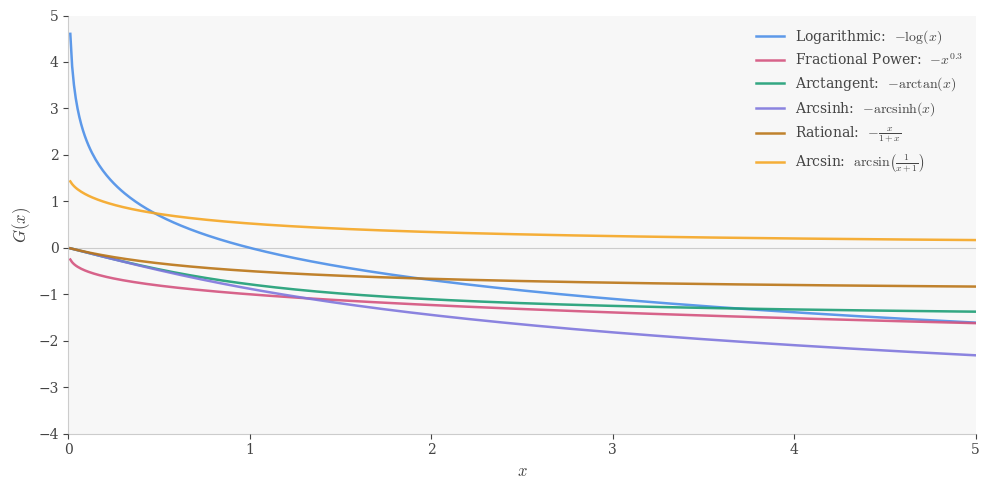


[2/9] plot_portfolio_delta
Saved -> /content/DeepHedging/figures/portfolio_delta_plot.pdf
Saved -> /content/DeepHedging/figures/portfolio_delta_plot.png


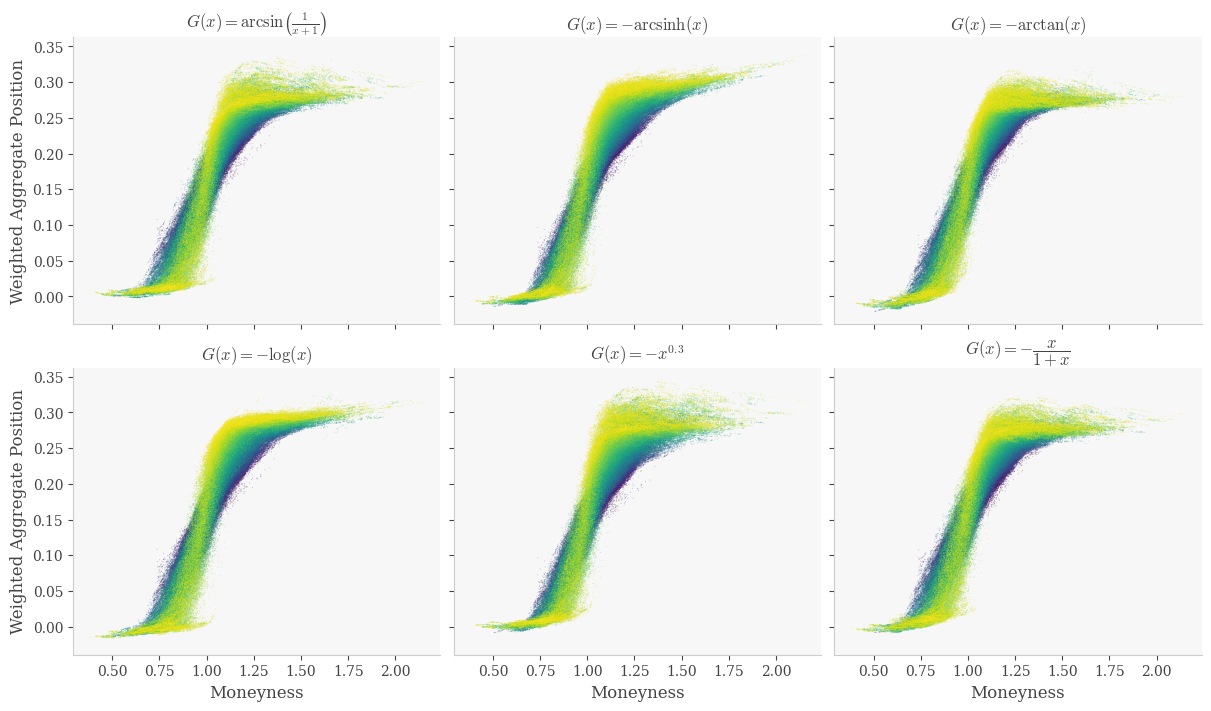


[3/9] plot_pnl_distributions
Saved -> /content/DeepHedging/figures/pnl_distributions.pdf
Saved -> /content/DeepHedging/figures/pnl_distributions.png


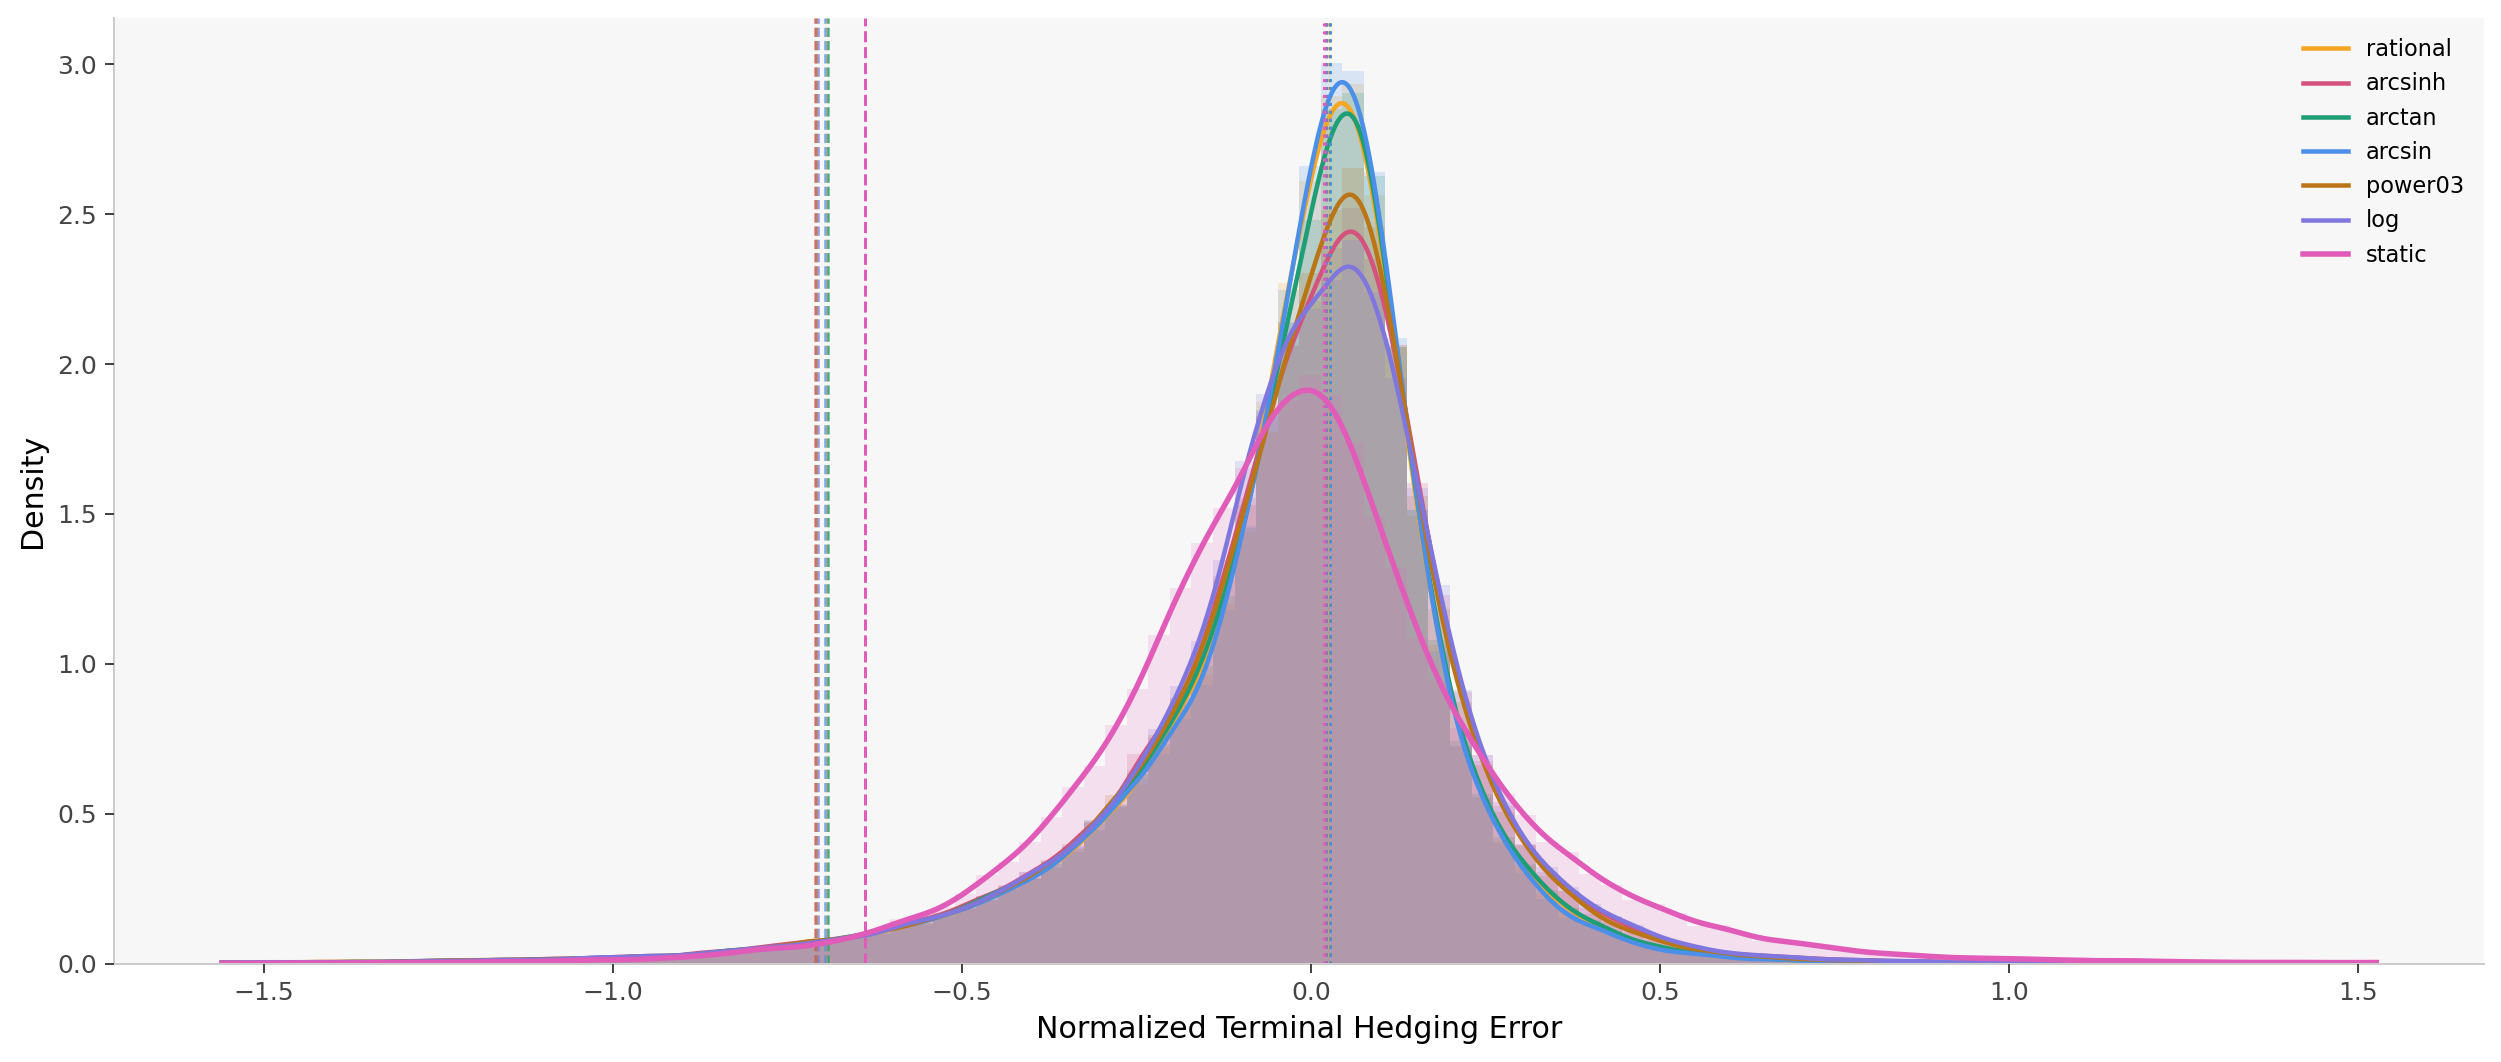


[4/9] plot_scoring_curvature
Saved -> /content/DeepHedging/figures/scoring_curvature_full.pdf
Saved -> /content/DeepHedging/figures/scoring_curvature_full.png


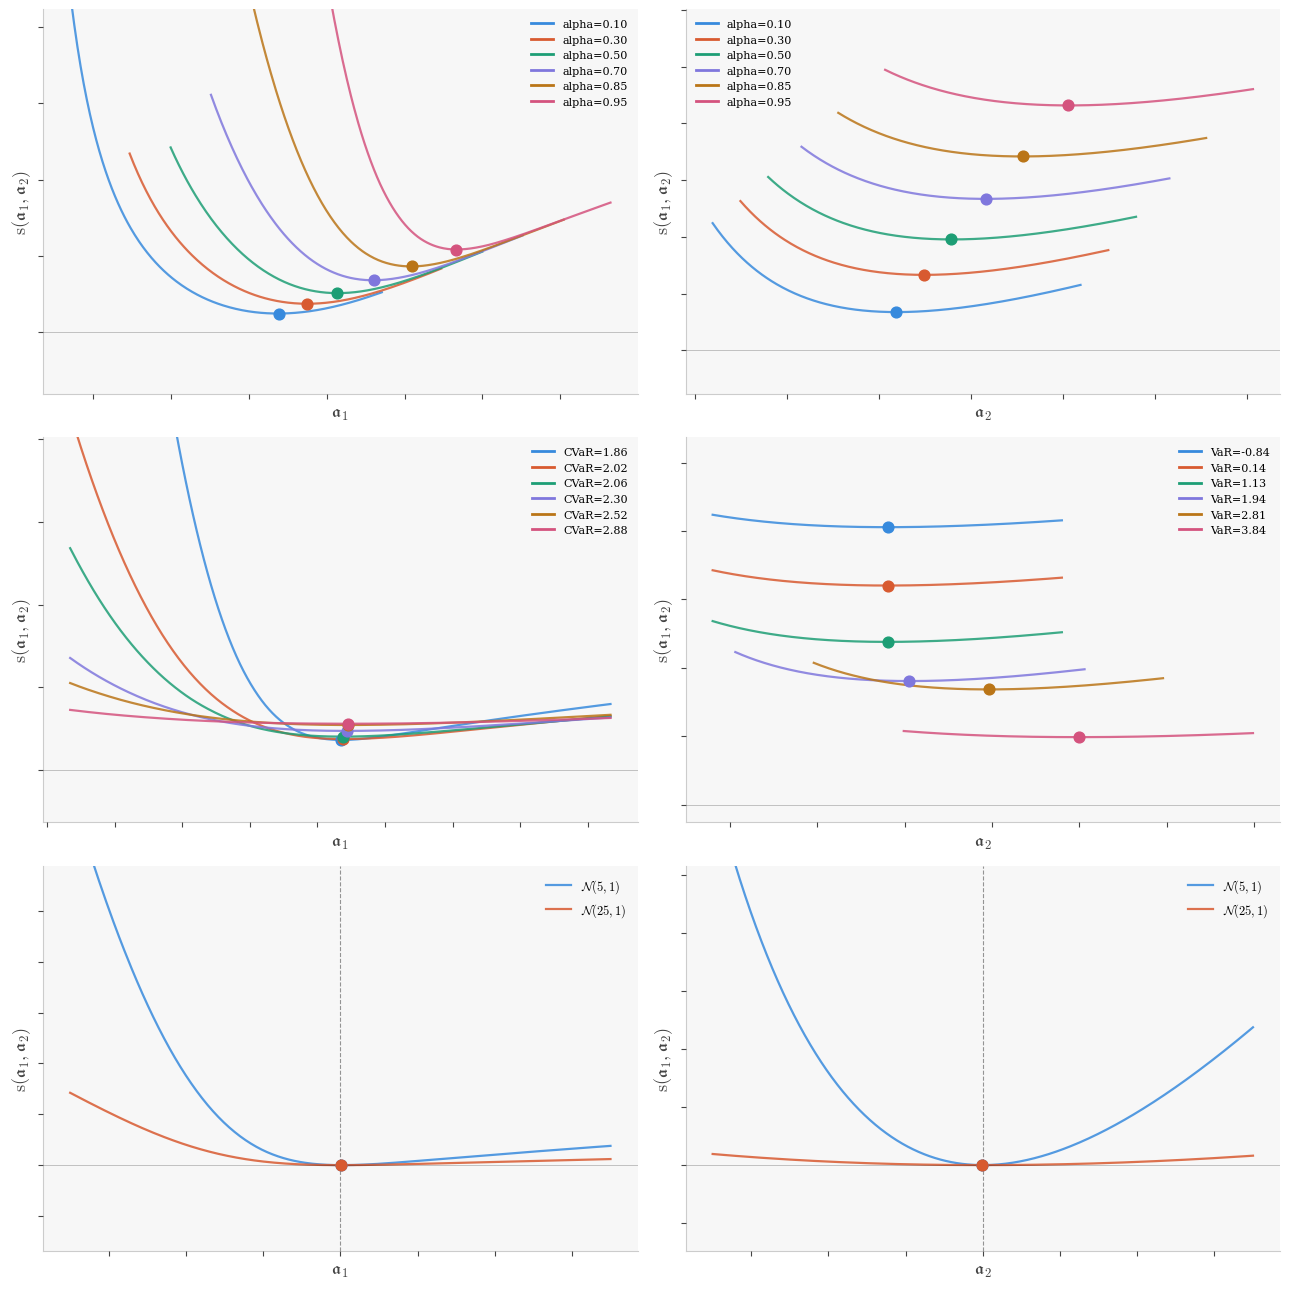


[5/9] plot_extreme_trajectory
Hard trajectory: idx=201  run-up=1.9391x  (basket start=89.35  end=173.26)
Saved -> /content/DeepHedging/figures/actions_hard_traj_4x2.pdf
Saved -> /content/DeepHedging/figures/actions_hard_traj_4x2.png


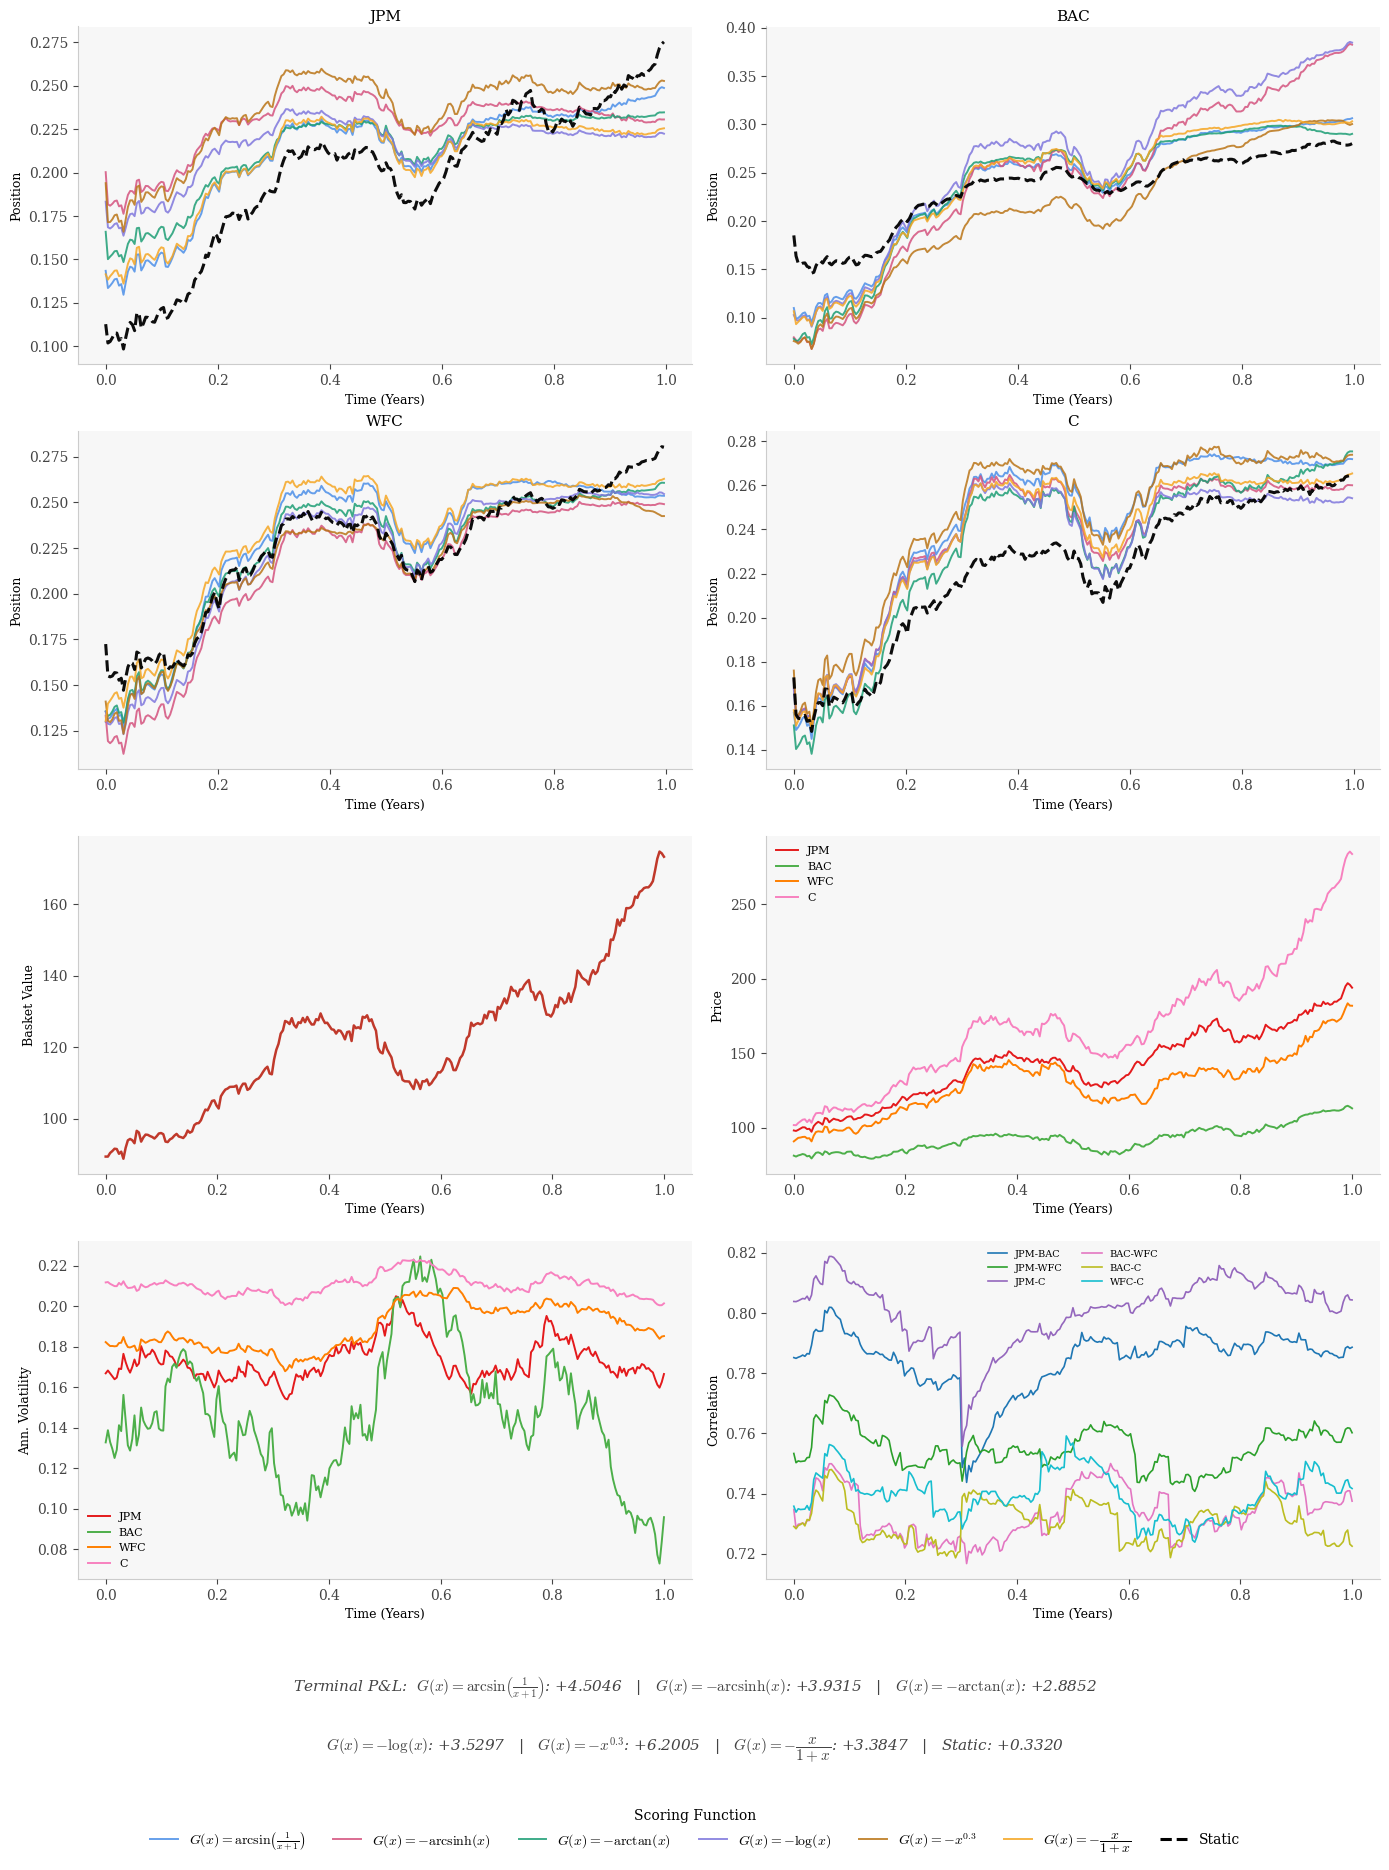


[6/9] plot_dynamic_risk_comparison
Saved -> /content/DeepHedging/figures/DynamicRiskComparison.pdf
Saved -> /content/DeepHedging/figures/DynamicRiskComparison.png


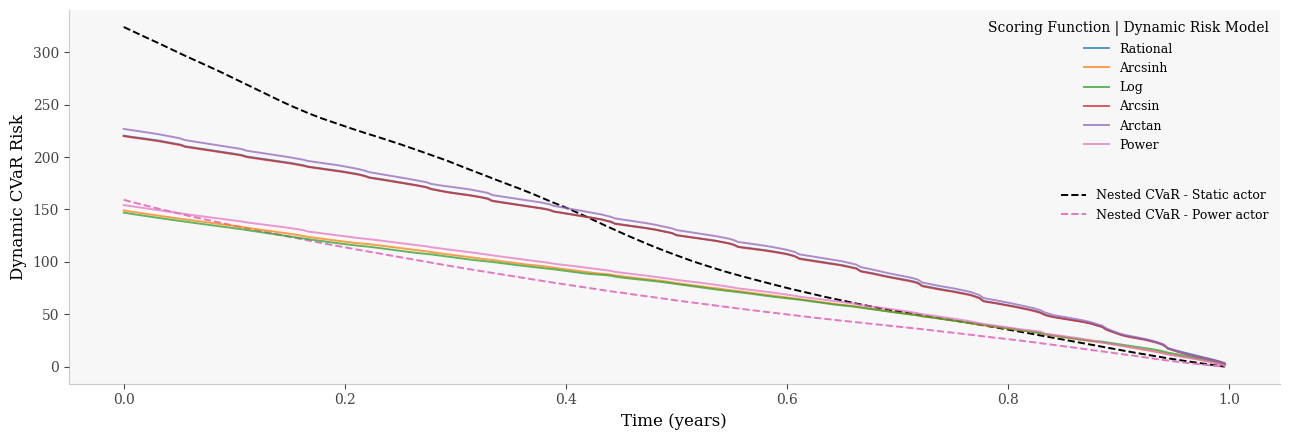


[7/9] plot_validation_risk
Saved -> /content/DeepHedging/figures/validation_risk.pdf
Saved -> /content/DeepHedging/figures/validation_risk.png


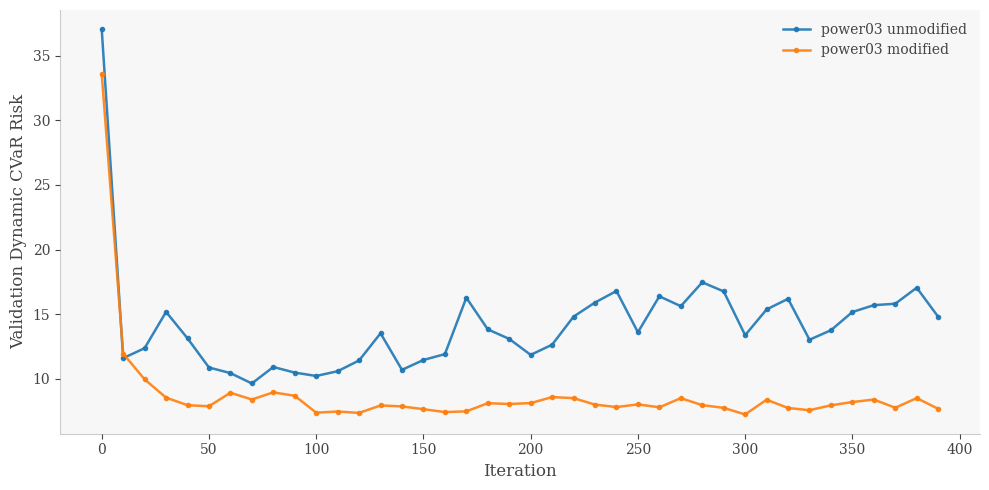


[8/9] plot_initial_dynamic_cvar
Saved -> /content/DeepHedging/figures/InitialDynamicCVaR.pdf
Saved -> /content/DeepHedging/figures/InitialDynamicCVaR.png


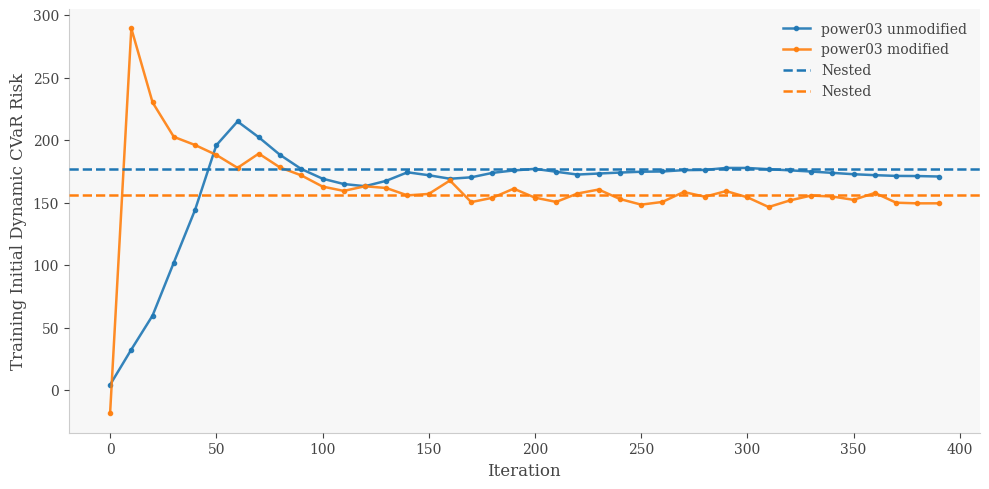


[9a/9] plot_actor_critic_loss
Saved -> /content/DeepHedging/figures/ALCL.pdf
Saved -> /content/DeepHedging/figures/ALCL.png


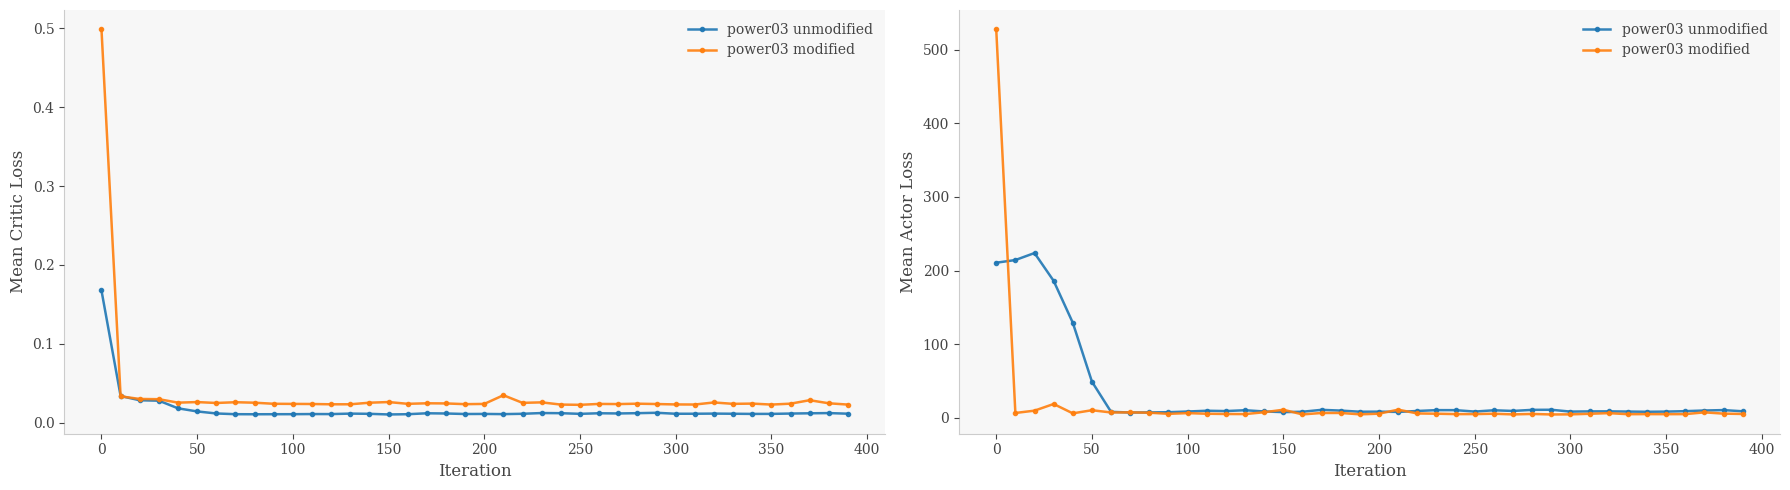


[9b/9] plot_mean_action
Saved -> /content/DeepHedging/figures/mean_action.pdf
Saved -> /content/DeepHedging/figures/mean_action.png


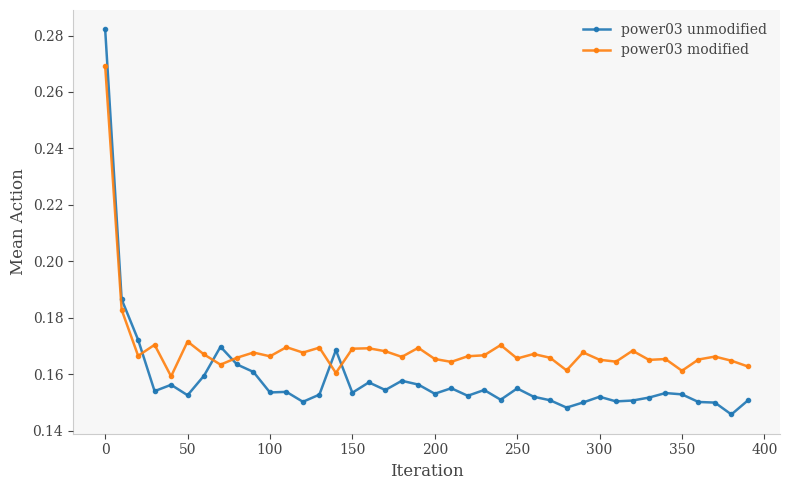

In [42]:
import importlib, src.visualization.plot as _plot_mod
importlib.reload(_plot_mod)

from src.visualization.plot import (
    plot_g2_functions, plot_portfolio_delta, plot_pnl_distributions,
    plot_scoring_curvature, plot_extreme_trajectory,
    plot_dynamic_risk_comparison, plot_validation_risk,
    plot_initial_dynamic_cvar, plot_actor_critic_loss, plot_mean_action,
)

print('\n[1/9] plot_g2_functions')
plot_g2_functions(save_dir=SAVE_DIR)

print('\n[2/9] plot_portfolio_delta')
plot_portfolio_delta(
    alpha_label=ALPHA_LABEL, data_dir=DATA_DIR,
    env=env, save_dir=SAVE_DIR, n_paths=1000,
)

print('\n[3/9] plot_pnl_distributions')
plot_pnl_distributions(
    alpha_label=ALPHA_LABEL, data_dir=DATA_DIR,
    save_dir=SAVE_DIR,
)

print('\n[4/9] plot_scoring_curvature')
plot_scoring_curvature(score_fn=score_fn, save_dir=SAVE_DIR)

print('\n[5/9] plot_extreme_trajectory')
plot_extreme_trajectory(
    alpha_label=ALPHA_LABEL, data_dir=DATA_DIR,
    env=env, save_dir=SAVE_DIR, n_paths=1000,
)

print('\n[6/9] plot_dynamic_risk_comparison')
plot_dynamic_risk_comparison(
    alpha_label=ALPHA_LABEL,
    data_dir=DATA_DIR,
    all_models=all_models,
    all_norms=all_norms,
    env=env,
    CriticVaRExcess=Critic_VaR_Excess,
    CriticCVaR=CriticCVaR,
    nested_ckpt_static_path=str(REPO / 'NestedCritics/critic_checkpoint_static_epoch4.pt'),
    nested_ckpt_dynamic_path=str(REPO / 'NestedCritics/critic_checkpoint_epoch4.pt'),
    save_dir=SAVE_DIR,
    n_paths=1000,
    risk_threshold=int(ALPHA_FLOAT * 100),
    n_groups=N_GROUPS,
)

print('\n[7/9] plot_validation_risk')
plot_validation_risk(log_files=LOG_FILES, save_dir=SAVE_DIR)

print('\n[8/9] plot_initial_dynamic_cvar')
plot_initial_dynamic_cvar(
    log_files=LOG_FILES,
    alpha_label=ALPHA_LABEL,
    data_dir=DATA_DIR,
    env=env,
    CriticCVaR=CriticCVaR,
    nested_ckpt_shift_path=str(REPO / 'NestedCritics/critic_checkpoint_epoch4.pt'),
    nested_ckpt_noshift_path=str(REPO / 'NestedCritics/critic_checkpoint_noshift_epoch4.pt'),
    save_dir=SAVE_DIR,
    n_groups=N_GROUPS,
)
print('\n[9a/9] plot_actor_critic_loss')
plot_actor_critic_loss(log_files=LOG_FILES, save_dir=SAVE_DIR)
print('\n[9b/9] plot_mean_action')
plot_mean_action(log_files=LOG_FILES, save_dir=SAVE_DIR)

In [41]:
print(open('/content/DeepHedging/src/visualization/plot.py').read())


"""
src/visualization/plot.py

All plotting utilities for:
  "Actor-critic Deep-hedging under Time-consistent Dynamic Risk"

All functions that previously called env.simulate_batch() now load from
pre-saved tensors generated by scripts/generate_data.py.

Data layout expected at data_dir (default "content/data"):
    <data_dir>/<alpha_label>/<scoring_key>/
        states.npy, actions.npy, log_probs.npy, costs.npy,
        portfolio_values.npy, deriv_prices.npy, PnL.npy,
        terminal_pnl.npy, S_paths.npy, h_paths.npy, R_paths.npy
    <data_dir>/<alpha_label>/static/
        (same files)

Public API
----------
plot_portfolio_delta(alpha_label, data_dir, env, save_dir)
plot_g2_functions(save_dir)
plot_pnl_distributions(alpha_label, data_dir, save_dir)
plot_scoring_curvature(score_fn, save_dir)
plot_extreme_trajectory(alpha_label, data_dir, env, save_dir)
plot_dynamic_risk_comparison(alpha_label, data_dir, all_models, all_norms,
                             env, CriticCVaR, nested_ckpt